<a href="https://colab.research.google.com/github/vzyhug/200123035_14DHTH07_DL/blob/main/CNN/CNN_multiclass_classification_prj1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DATASET

In [1]:
# Cài đặt thư viện kaggle
!pip install -q kaggle

# 1. Upload file kaggle.json từ máy tính của bạn lên Colab
from google.colab import files
print("Vui lòng tải lên tệp kaggle.json của bạn:")
files.upload()

# 2. Thiết lập quyền truy cập API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Tải dataset Animals và tự động giải nén vào thư mục /content/animal_data
print("\nĐang tải và giải nén dữ liệu...")
!kaggle datasets download -d antobenedetti/animals --unzip -p /content/animal_data
print("Hoàn tất tải dữ liệu!")

Vui lòng tải lên tệp kaggle.json của bạn:


Saving kaggle.json to kaggle (1).json

Đang tải và giải nén dữ liệu...
Dataset URL: https://www.kaggle.com/datasets/antobenedetti/animals
License(s): GPL-2.0
100% 882M/882M [00:04<00:00, 224MB/s]

Hoàn tất tải dữ liệu!


## IMPORT

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
from google.colab import drive
drive.mount('/content/drive')

# Cấu hình siêu tham số
BATCH_SIZE = 32
EPOCHS = 15          # Số vòng huấn luyện
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang chạy trên thiết bị: {DEVICE}")

# Dựa theo cấu trúc giải nén của Kaggle, đường dẫn sẽ là:
DATA_DIR = '/content/animal_data/animals'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'val')
SAVE_DIR = '/content/drive/MyDrive/animal_cnn_best_model.pth'

Mounted at /content/drive
Đang chạy trên thiết bị: cuda


## PREPROCESSING

In [3]:
# 1. Data Augmentation cho tập Train
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # 50% cơ hội lật ảnh
    transforms.RandomRotation(15),          # Xoay tối đa 15 độ
    transforms.ToTensor(),                  # Chuyển thành tensor có giá trị [0, 1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Chuẩn hóa theo ImageNet
])

# 2. Tập Validation chỉ Resize và Chuẩn hóa (Không thay đổi cấu trúc ảnh)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Tạo Dataset và DataLoader
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Xem thông tin dữ liệu
classes = train_dataset.classes
print(f"Danh sách các lớp ({len(classes)} loài): {classes}")
print(f"Tổng số ảnh Train: {len(train_dataset)}")
print(f"Tổng số ảnh Val: {len(val_dataset)}")

Danh sách các lớp (5 loài): ['cat', 'dog', 'elephant', 'horse', 'lion']
Tổng số ảnh Train: 13474
Tổng số ảnh Val: 1497


## DEFINE STRUCTURE CNN

In [4]:
class AnimalCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(AnimalCNN, self).__init__()

        # Đặc trưng hình ảnh
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Giảm kích thước ảnh đi một nửa

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Tại đây, kích thước ảnh 224x224 đã bị nén 3 lần (chia 8) -> 28x28

        # Phân loại
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # Ngắt kết nối 50% nơ-ron để tránh học vẹt
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Khởi tạo mô hình và đưa lên GPU
model = AnimalCNN(num_classes=len(classes)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## TRAIN

In [11]:
import time
import sys
import torch

# --- CẤU HÌNH EARLY STOPPING & LƯU MODEL ---
best_val_acc = 0.0
best_val_loss = float('inf')
patience = 3          # Số epoch tối đa chịu đựng nếu val_loss không giảm thêm
patience_counter = 0  # Bộ đếm số epoch không cải thiện

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Bắt đầu quá trình huấn luyện... Vui lòng giữ tab mở!")

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")

    # -------- TRAIN PHASE --------
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    start_time = time.time()
    num_batches = len(train_loader)

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Tính toán các chỉ số hiện tại
        current_loss = running_loss / (i + 1)
        current_acc = correct_train / total_train

        # Tính thời gian elapsed và thời gian mỗi bước (step)
        elapsed = time.time() - start_time
        step_time = elapsed / (i + 1) if (i + 1) > 0 else 0

        # Tạo thanh tiến trình (progress bar) kiểu Keras
        bar_length = 30
        progress = float(i + 1) / num_batches
        arrow = '=' * int(round(progress * bar_length) - 1) + '>' if progress < 1.0 else '=' * bar_length
        spaces = '.' * (bar_length - len(arrow))

        # In ra màn hình và ghi đè dòng liên tục bằng \r
        sys.stdout.write(f"\r{i+1}/{num_batches} [{arrow}{spaces}] - {int(elapsed)}s {step_time:.0f}s/step - accuracy: {current_acc:.4f} - loss: {current_loss:.4f}")
        sys.stdout.flush()

    # -------- VALIDATION PHASE --------
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = correct_val / total_val

    # Cập nhật dòng cuối cùng của Epoch (bổ sung thêm val_loss và val_accuracy)
    sys.stdout.write(f"\r{num_batches}/{num_batches} [{'=' * bar_length}] - {int(elapsed)}s {step_time:.0f}s/step - accuracy: {current_acc:.4f} - loss: {current_loss:.4f} - val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}\n")

    # Lưu lịch sử để vẽ biểu đồ (Đặt ở vị trí chuẩn xác)
    history['train_loss'].append(current_loss)
    history['train_acc'].append(current_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # -------- LƯU MODEL DỰA TRÊN VAL_ACCURACY --------
    if val_acc > best_val_acc:
        print(f"Epoch {epoch+1}: val_accuracy improved from {best_val_acc:.5f} to {val_acc:.5f}, saving model to {SAVE_DIR}")
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_DIR)
    else:
        print(f"Epoch {epoch+1}: val_accuracy did not improve from {best_val_acc:.5f}")

    # -------- XỬ LÝ EARLY STOPPING (Theo dõi val_loss) --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0  # Reset bộ đếm nếu val_loss có cải thiện (giảm xuống)
    else:
        patience_counter += 1
        print(f"EarlyStopping counter: {patience_counter} out of {patience}")

    if patience_counter >= patience:
        print(f"Epoch {epoch+1:02d}: Early Stopping! Mô hình dừng sớm để tránh Overfitting.")
        break

    print("-" * 50) # Đường phân cách giữa các Epoch

print("--- QUÁ TRÌNH HUẤN LUYỆN KẾT THÚC ---")

Bắt đầu quá trình huấn luyện... Vui lòng giữ tab mở!
Epoch 1/15
422/422 [==============================] - 108s 0s/step - accuracy: 0.7871 - loss: 0.5441 - val_accuracy: 0.8310 - val_loss: 0.4116
Epoch 1: val_accuracy improved from 0.00000 to 0.83100, saving model to /content/drive/MyDrive/animal_cnn_best_model.pth
--------------------------------------------------
Epoch 2/15
422/422 [==============================] - 110s 0s/step - accuracy: 0.8015 - loss: 0.5040 - val_accuracy: 0.8530 - val_loss: 0.3845
Epoch 2: val_accuracy improved from 0.83100 to 0.85304, saving model to /content/drive/MyDrive/animal_cnn_best_model.pth
--------------------------------------------------
Epoch 3/15
422/422 [==============================] - 105s 0s/step - accuracy: 0.8217 - loss: 0.4587 - val_accuracy: 0.8076 - val_loss: 0.4525
Epoch 3: val_accuracy did not improve from 0.85304
--------------------------------------------------
Epoch 4/15
422/422 [==============================] - 103s 0s/step - acc

## VISUALIZATION

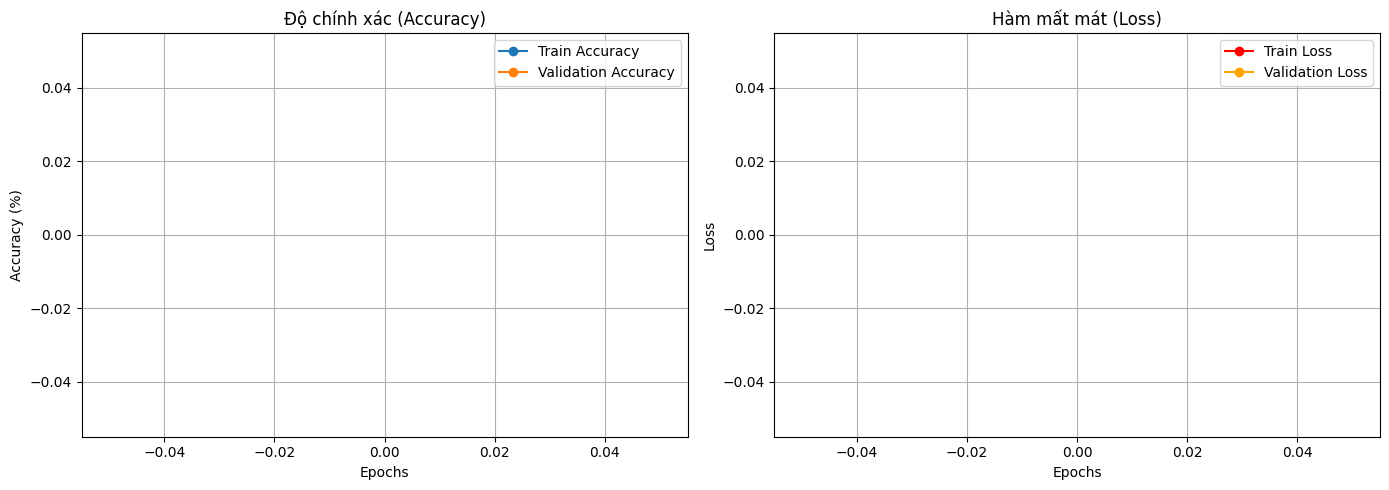


Đang tính toán Ma trận nhầm lẫn trên tập Validation...


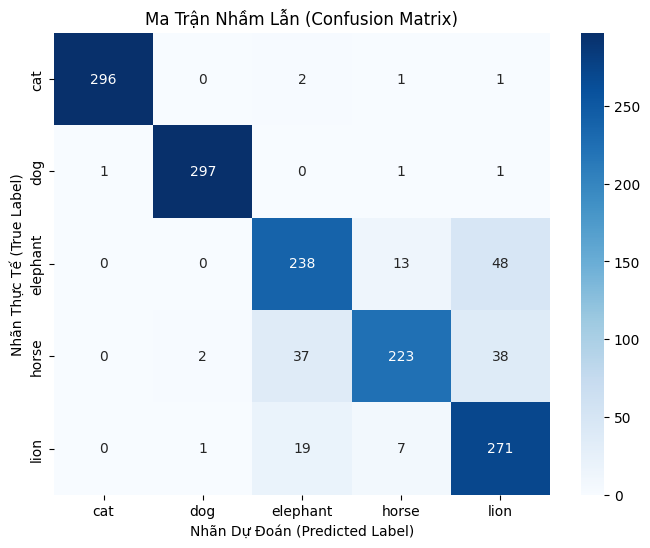

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torch

# ==========================================
# 1. VẼ BIỂU ĐỒ ACCURACY VÀ LOSS
# ==========================================
epochs_range = range(1, len(history['train_acc']) + 1)

plt.figure(figsize=(14, 5))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='o')
plt.title('Độ chính xác (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='red', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='orange', marker='o')
plt.title('Hàm mất mát (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 2. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
# ==========================================
print("\nĐang tính toán Ma trận nhầm lẫn trên tập Validation...")

model.eval()
all_preds = []
all_labels = []

# Trích xuất toàn bộ dự đoán từ tập Validation
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Tính toán Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Vẽ ma trận trực quan
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix)')
plt.ylabel('Nhãn Thực Tế (True Label)')
plt.xlabel('Nhãn Dự Đoán (Predicted Label)')
plt.show()

## SIMPLE TEST

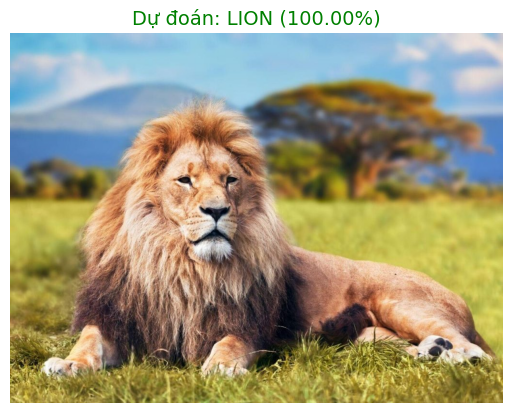

In [15]:
import requests
from PIL import Image
from io import BytesIO

# 1. Thay thế link URL ảnh con vật bạn muốn test tại đây
URL_ANH = "https://s3-ap-southeast-1.amazonaws.com/cntatr-assets-ap-southeast-1-250226768838-55a62c9399d4d8a6/2024/09/su-tu-3-1024x768.jpeg?tr=q-70,c-at_max,w-1000,h-600"

try:
    # Tải ảnh từ internet
    response = requests.get(URL_ANH)
    img = Image.open(BytesIO(response.content)).convert('RGB')

    # Áp dụng các bước tiền xử lý giống hệt tập Validation
    img_tensor = val_transforms(img).unsqueeze(0) # Thêm chiều batch (1, 3, 224, 224)

    # Dự đoán bằng mô hình đã train
    model.eval()
    with torch.no_grad():
        img_tensor = img_tensor.to(DEVICE)
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)

    ten_loai_vat = classes[predicted_idx.item()]
    do_tuat_doi = confidence.item() * 100

    # Hiển thị ảnh và kết quả dự đoán
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Dự đoán: {ten_loai_vat.upper()} ({do_tuat_doi:.2f}%)", fontsize=14, color='green')
    plt.show()

except Exception as e:
    print(f"Lỗi khi tải hoặc xử lý ảnh: {e}. Vui lòng kiểm tra lại link URL ảnh.")